In [1]:
import graph_helper_functions
from graph_helper_functions import *
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import igraph as ig
from igraph import plot
from sympy.abc import x, y
from qldpc import codes, circuits
from qldpc.objects import Pauli
import numpy as np
from collections import defaultdict, deque

In [27]:
import sys, shutil, importlib

sys.path.insert(0, "/mnt/data")

import graph_helper_functions as gh
importlib.reload(gh)

from graph_helper_functions import *

In [14]:
# construct tanner graph from merged codes
import numpy as np
import json
from graph_helper_functions import deform_code_for_logical
from graph_helper_functions import split_heavy_cycles
import numpy as np

def tanner_graph_from_deformations(
    deformation_result1,
    deformation_result2,
    basis="X",
    coords=None,
):
    merge_result = auxiliary_merge(deformation_result1, deformation_result2)

    return tanner_graph_from_merge_result_remapped(
        merge_result=merge_result,
        deformation_result1=deformation_result1,
        deformation_result2=deformation_result2,
        basis=basis,
        coords=coords,
    )


def tanner_graph_from_merge_result_remapped(
    merge_result,
    deformation_result1,
    deformation_result2,
    basis="X",
    coords=None,
):
    n_data1 = deformation_result1["n_original_qubits"]
    n_data2 = deformation_result2["n_original_qubits"]
    n_edges1 = deformation_result1["n_edges"]
    n_edges2 = deformation_result2["n_edges"]

    n_q1 = deformation_result1["n_qubits"]
    n_q2 = deformation_result2["n_qubits"]

    n_adapter = merge_result["n_adapter_edges"]

    # Desired ordering:
    # [data1 | data2 | edges1 | edges2 | adapters]
    offset_data1 = 0
    offset_data2 = n_data1
    offset_edge1 = n_data1 + n_data2
    offset_edge2 = n_data1 + n_data2 + n_edges1
    offset_adapter = n_data1 + n_data2 + n_edges1 + n_edges2

    n_total = offset_adapter + n_adapter

    def classify_check_block(
        support,
        offset_data1,
        offset_edge1,
        offset_data2,
        offset_edge2,
        offset_adapter,
        n_data1,
        n_edges1,
        n_data2,
        n_edges2,
        n_adapter,
    ):
        support = set(map(int, support))

        ranges = {
            "code1_data": set(range(offset_data1, offset_data1 + n_data1)),
            "code2_data": set(range(offset_data2, offset_data2 + n_data2)),
            "code1_gadget": set(range(offset_edge1, offset_edge1 + n_edges1)),
            "code2_gadget": set(range(offset_edge2, offset_edge2 + n_edges2)),
            "adapter": set(range(offset_adapter, offset_adapter + n_adapter)),
        }

        touched = [name for name, r in ranges.items() if support & r]

        if touched == ["code1_data"]:
            return "code1"
        if touched == ["code2_data"]:
            return "code2"
        if "adapter" in touched:
            return "adapter_or_merge"
        if any("gadget" in t for t in touched):
            return "deformed_or_gadget"
        if "code1_data" in touched and "code2_data" in touched:
            return "code_merge"
        return "mixed"

    def map_column(j):
        # Original auxiliary_merge ordering:
        # [data1 | edges1 | data2 | edges2 | adapters]
        if j < n_data1:
            return offset_data1 + j
        elif j < n_q1:
            return offset_edge1 + (j - n_data1)
        elif j < n_q1 + n_data2:
            return offset_data2 + (j - n_q1)
        elif j < n_q1 + n_q2:
            return offset_edge2 + (j - n_q1 - n_data2)
        else:
            return offset_adapter + (j - n_q1 - n_q2)

    def matrix_to_supports(M):
        supports = []
        for row in np.asarray(M, dtype=np.uint8):
            cols = np.where(row == 1)[0]
            supports.append(np.array([map_column(int(j)) for j in cols], dtype=int))
        return supports

    H_basis_supports = matrix_to_supports(merge_result["H_basis"])
    H_opposite_supports = matrix_to_supports(merge_result["H_opposite_basis"])

    if basis == "X":
        X_supports = H_basis_supports
        Z_supports = H_opposite_supports
    elif basis == "Z":
        Z_supports = H_basis_supports
        X_supports = H_opposite_supports
    else:
        raise ValueError("basis must be 'X' or 'Z'.")

    nodes = []
    links = []

    def get_coord(q_global):
        if coords is None:
            return (0.0, 0.0, 0.0)
        if q_global in coords:
            return coords[q_global]
        key = f"q_{q_global}"
        if key in coords:
            return coords[key]
        return (0.0, 0.0, 0.0)

    def add_qubit_node(q_global, qubit_type, block, original_index, fixed):
        x, y, z = get_coord(q_global)
        nodes.append({
            "id": f"q_{int(q_global)}",
            "kind": "qubit",
            "qubit_type": qubit_type,
            "block": block,
            "global_index": int(q_global),
            "original_index": int(original_index),
            "x": float(x),
            "y": float(y),
            "z": float(z),
            "fixed": bool(fixed),
        })

    # Qubits in desired order
    for i in range(n_data1):
        add_qubit_node(offset_data1 + i, "data", "code1", i, True)

    for i in range(n_data2):
        add_qubit_node(offset_data2 + i, "data", "code2", i, True)

    for e in range(n_edges1):
        add_qubit_node(offset_edge1 + e, "aux_edge", "code1_gadget", e, False)

    for e in range(n_edges2):
        add_qubit_node(offset_edge2 + e, "aux_edge", "code2_gadget", e, False)

    for a in range(n_adapter):
        add_qubit_node(offset_adapter + a, "adapter", "adapter", a, False)

    def add_check_nodes_and_links(supports, check_type):
        for r, support in enumerate(supports):
            support = np.asarray(support, dtype=int)
            check_id = f"{check_type.lower()}_{r}"

            nodes.append({
                "id": check_id,
                "kind": "check",
                "check_type": check_type,
                "block": classify_check_block(
                    support=support,
                    offset_data1=offset_data1,
                    offset_edge1=offset_edge1,
                    offset_data2=offset_data2,
                    offset_edge2=offset_edge2,
                    offset_adapter=offset_adapter,
                    n_data1=n_data1,
                    n_edges1=n_edges1,
                    n_data2=n_data2,
                    n_edges2=n_edges2,
                    n_adapter=n_adapter,
                ),
                "row_index": int(r),
                "weight": int(len(support)),
                "fixed": False,
            })

            for q in support:
                links.append({
                    "source": check_id,
                    "target": f"q_{int(q)}",
                    "interaction": "check_support",
                    "pauli": check_type,
                    "check_row": int(r),
                })

    add_check_nodes_and_links(X_supports, "X")
    add_check_nodes_and_links(Z_supports, "Z")

    return {
        "nodes": nodes,
        "links": links,
        "metadata": {
            "n_total_qubits": int(n_total),
            "n_data1": int(n_data1),
            "n_data2": int(n_data2),
            "n_edges1": int(n_edges1),
            "n_edges2": int(n_edges2),
            "n_adapter_edges": int(n_adapter),
            "ordering": ["data1", "data2", "edges1", "edges2", "adapter"],
            "offsets": {
                "data1": int(offset_data1),
                "data2": int(offset_data2),
                "edge1": int(offset_edge1),
                "edge2": int(offset_edge2),
                "adapter": int(offset_adapter),
            },
        },
    }

In [15]:
surface_code = codes.SurfaceCode(4, 4)
a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 6, y: 6}
BB_code = codes.BBCode(orders=orders, poly_a=a, poly_b=b)

code = BB_code
logical = code.get_logical_ops(Pauli.X)[0]
d1 = deform_code_for_logical(code.matrix, basis=Pauli.X, logical=logical)
d2 = deform_code_for_logical(code.matrix, basis=Pauli.X, logical=logical)
res = tanner_graph_from_deformations(d1, d2)


In [16]:
from collections import Counter
import numpy as np

nodes = res["nodes"]
links = res["links"]

qubits = [n for n in nodes if n["kind"] == "qubit"]
checks = [n for n in nodes if n["kind"] == "check"]

print("=" * 60)
print("TANNER GRAPH SUMMARY")
print("=" * 60)

print(f"total nodes   : {len(nodes)}")
print(f"qubit nodes   : {len(qubits)}")
print(f"check nodes   : {len(checks)}")
print(f"links         : {len(links)}")

print("\nqubit types:")
print(Counter(q["qubit_type"] for q in qubits))

print("\ncheck types:")
print(Counter(c["check_type"] for c in checks))

print("\ncheck blocks:")
print(Counter(c["block"] for c in checks))

print("\nfirst 5 nodes:")
for n in nodes[:5]:
    print(n)

print("\nfirst 5 links:")
for l in links[:5]:
    print(l)

print("=" * 60)

TANNER GRAPH SUMMARY
total nodes   : 367
qubit nodes   : 184
check nodes   : 183
links         : 1072

qubit types:
Counter({'data': 144, 'aux_edge': 32, 'adapter': 8})

check types:
Counter({'Z': 95, 'X': 88})

check blocks:
Counter({'code1': 60, 'code2': 60, 'deformed_or_gadget': 40, 'adapter_or_merge': 23})

first 5 nodes:
{'id': 'q_0', 'kind': 'qubit', 'qubit_type': 'data', 'block': 'code1', 'global_index': 0, 'original_index': 0, 'x': 0.0, 'y': 0.0, 'z': 0.0, 'fixed': True}
{'id': 'q_1', 'kind': 'qubit', 'qubit_type': 'data', 'block': 'code1', 'global_index': 1, 'original_index': 1, 'x': 0.0, 'y': 0.0, 'z': 0.0, 'fixed': True}
{'id': 'q_2', 'kind': 'qubit', 'qubit_type': 'data', 'block': 'code1', 'global_index': 2, 'original_index': 2, 'x': 0.0, 'y': 0.0, 'z': 0.0, 'fixed': True}
{'id': 'q_3', 'kind': 'qubit', 'qubit_type': 'data', 'block': 'code1', 'global_index': 3, 'original_index': 3, 'x': 0.0, 'y': 0.0, 'z': 0.0, 'fixed': True}
{'id': 'q_4', 'kind': 'qubit', 'qubit_type': 'da

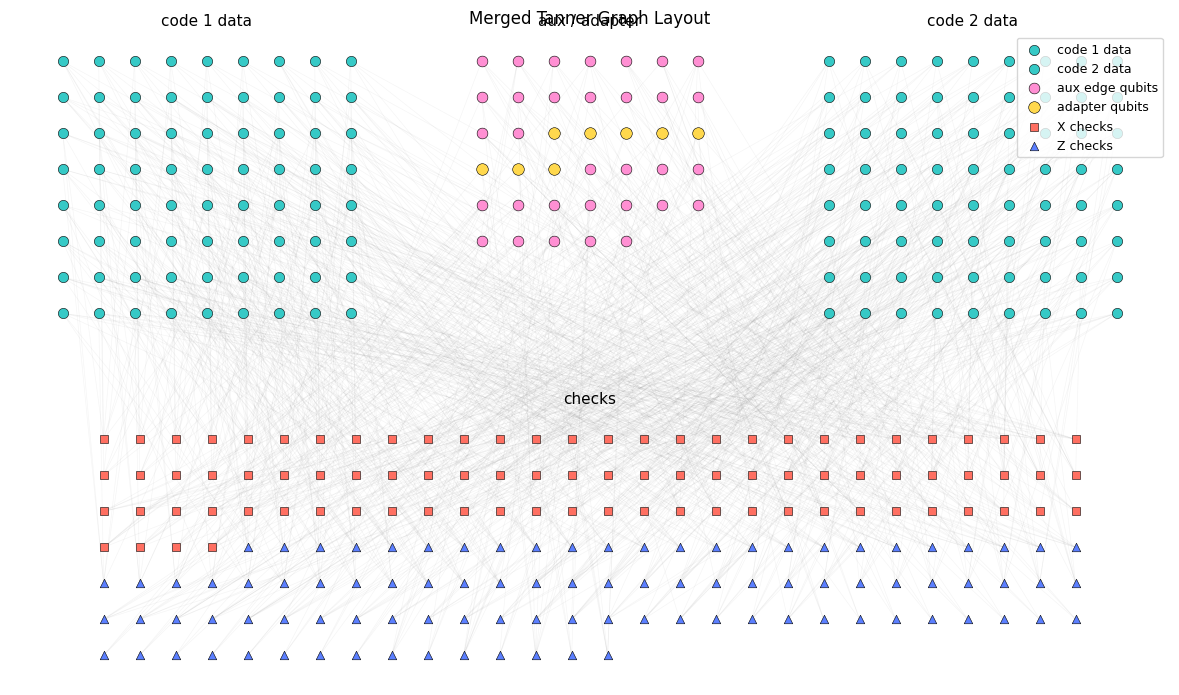

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

def plot_tanner_three_patch(
    res,
    show_labels=False,
    max_patch_cols=20,
    max_check_cols=100,
    dx=0.55,
    dy=0.55,
    gap=2,
    figsize=None,
):
    nodes = res["nodes"]
    links = res["links"]
    meta = res["metadata"]
    offsets = meta["offsets"]

    n_data1 = meta["n_data1"]
    n_data2 = meta["n_data2"]
    n_edges1 = meta["n_edges1"]
    n_edges2 = meta["n_edges2"]
    n_adapter = meta["n_adapter_edges"]

    data1_ids = [f"q_{i}" for i in range(offsets["data1"], offsets["data1"] + n_data1)]
    edge1_ids = [f"q_{i}" for i in range(offsets["edge1"], offsets["edge1"] + n_edges1)]
    data2_ids = [f"q_{i}" for i in range(offsets["data2"], offsets["data2"] + n_data2)]
    edge2_ids = [f"q_{i}" for i in range(offsets["edge2"], offsets["edge2"] + n_edges2)]
    adapter_ids = [f"q_{i}" for i in range(offsets["adapter"], offsets["adapter"] + n_adapter)]

    center_ids = edge1_ids + adapter_ids + edge2_ids
    check_ids = [n["id"] for n in nodes if n["kind"] == "check"]
    xcheck_ids = [n["id"] for n in nodes if n["kind"] == "check" and n["check_type"] == "X"]
    zcheck_ids = [n["id"] for n in nodes if n["kind"] == "check" and n["check_type"] == "Z"]

    def grid_dims(n, max_cols):
        cols = min(max_cols, max(1, int(np.ceil(np.sqrt(n)))))
        rows = int(np.ceil(n / cols))
        return rows, cols

    def place_grid(ids, x0, y0, cols, pos):
        for k, node_id in enumerate(ids):
            r = k // cols
            c = k % cols
            pos[node_id] = np.array([x0 + c * dx, y0 - r * dy])

    r1, c1 = grid_dims(len(data1_ids), max_patch_cols)
    rc, cc = grid_dims(len(center_ids), max_patch_cols)
    r2, c2 = grid_dims(len(data2_ids), max_patch_cols)

    w1 = max(1, c1 - 1) * dx
    wc = max(1, cc - 1) * dx
    w2 = max(1, c2 - 1) * dx

    x1 = 0
    xc = x1 + w1 + gap
    x2 = xc + wc + gap

    y_top = 0
    pos = {}

    place_grid(data1_ids, x1, y_top, c1, pos)
    place_grid(center_ids, xc, y_top, cc, pos)
    place_grid(data2_ids, x2, y_top, c2, pos)

    total_width = x2 + w2
    center_x = total_width / 2

    check_cols = min(max_check_cols, max(1, int(np.ceil(np.sqrt(len(check_ids) * 4)))))
    check_rows = int(np.ceil(len(check_ids) / check_cols))
    check_width = max(1, check_cols - 1) * dx
    check_x0 = center_x - check_width / 2

    max_patch_rows = max(r1, rc, r2)
    check_y0 = y_top - (max_patch_rows + 2.5) * dy

    place_grid(check_ids, check_x0, check_y0, check_cols, pos)

    if figsize is None:
        fig_w = min(28, max(12, total_width * 0.75))
        fig_h = min(18, max(7, (max_patch_rows + check_rows) * 0.45))
        figsize = (fig_w, fig_h)

    fig, ax = plt.subplots(figsize=figsize)

    for e in links:
        s, t = e["source"], e["target"]
        if s in pos and t in pos:
            ax.plot(
                [pos[s][0], pos[t][0]],
                [pos[s][1], pos[t][1]],
                color="gray",
                alpha=0.08,
                lw=0.5,
                zorder=0,
            )

    def draw(ids, color, marker, size, label):
        ids = [i for i in ids if i in pos]
        if not ids:
            return
        ax.scatter(
            [pos[i][0] for i in ids],
            [pos[i][1] for i in ids],
            c=color,
            marker=marker,
            s=size,
            edgecolors="k",
            linewidths=0.4,
            label=label,
            zorder=3,
        )

    draw(data1_ids, "#36c9c6", "o", 55, "code 1 data")
    draw(data2_ids, "#36c9c6", "o", 55, "code 2 data")
    draw(edge1_ids + edge2_ids, "#ff8fd3", "o", 60, "aux edge qubits")
    draw(adapter_ids, "#ffd84d", "o", 70, "adapter qubits")
    draw(xcheck_ids, "#ff6f61", "s", 38, "X checks")
    draw(zcheck_ids, "#5b7fff", "^", 38, "Z checks")

    if show_labels:
        for node_id, p in pos.items():
            ax.text(p[0], p[1], node_id, fontsize=5, ha="center", va="center", zorder=4)

    ax.text(x1 + w1 / 2, y_top + dy, "code 1 data", ha="center", fontsize=11)
    ax.text(xc + wc / 2, y_top + dy, "aux / adapter", ha="center", fontsize=11)
    ax.text(x2 + w2 / 2, y_top + dy, "code 2 data", ha="center", fontsize=11)
    ax.text(center_x, check_y0 + dy, "checks", ha="center", fontsize=11)

    ax.legend(loc="upper right", fontsize=9)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Merged Tanner Graph Layout")
    plt.tight_layout()

    return fig, ax, pos

fig, ax, pos = plot_tanner_three_patch(res, show_labels=False)
plt.show()





In [18]:
logical_ops_x = np.where(BB_code.get_logical_ops(Pauli.X)[0]==1)
logical_ops_z = BB_code.get_logical_ops(Pauli.Z)

print(logical_ops_x)

(array([20, 23, 26, 29, 40, 41, 55, 56]),)


## Visualize BB code with d3

In [19]:
import json
import math
import numpy as np

def write_bb_tanner_graph_torus_json(
    BB_code,
    json_path="bb_tanner_graph.json",
    ell=6,
    m=6,
    R_major=120.0,
    r_minor=65.0,
):
    H = np.asarray(BB_code.matrix, dtype=np.uint8)
   
    n_data = H.shape[1] // 2
    n_checks = H.shape[0]
    n_sites = ell * m
    n_x_checks = n_checks // 2

    assert n_data == 2 * n_sites
    assert n_checks == 2 * n_sites

    def torus_xyz(u, v):
        U = 2 * m
        V = 2 * ell
        theta = 2 * math.pi * u / U
        phi = 2 * math.pi * v / V

        x = (R_major + r_minor * math.cos(phi)) * math.cos(theta)
        y = (R_major + r_minor * math.cos(phi)) * math.sin(theta)
        z = r_minor * math.sin(phi)
        return float(x), float(y), float(z)

    def site_to_ab(i):
        a = i // m
        b = i % m
        return a, b

    def add_node(nodes, node_id, kind, register, index, u, v, check_type=None):
        x, y, z = torus_xyz(u, v)
        node = {
            "id": node_id,
            "kind": kind,
            "register": register,
            "index": int(index),
            "u": int(u),
            "v": int(v),
            "x": x, "y": y, "z": z,
            "fx": x, "fy": y, "fz": z,
        }
        if check_type is not None:
            node["check_type"] = check_type
        nodes.append(node)

    nodes = []
    links = []

    # BB toric unit cell:
    # L = (even, even), X = (odd, even), Z = (even, odd), R = (odd, odd)
    for i in range(n_sites):
        a, b = site_to_ab(i)
        add_node(nodes, f"q_{i}", "data", "L", i, 2 * b, 2 * a)

    for i in range(n_sites):
        a, b = site_to_ab(i)
        add_node(nodes, f"q_{n_sites + i}", "data", "R", i, 2 * b + 1, 2 * a + 1)

    for i in range(n_sites):
        a, b = site_to_ab(i)
        add_node(nodes, f"x_{i}", "check", "X", i, 2 * b + 1, 2 * a, check_type="X")

    for i in range(n_sites):
        a, b = site_to_ab(i)
        add_node(nodes, f"z_{i}", "check", "Z", i, 2 * b, 2 * a + 1, check_type="Z")

    # Tanner links
    for r in range(n_x_checks):
        support = np.where(H[r, :n_data] == 1)[0]
        for q in support:
            links.append({
                "source": f"x_{r}",
                "target": f"q_{int(q)}",
                "kind": "tanner_edge",
                "check_type": "X",
                "visual_only": True,
            })

    for r in range(n_x_checks, n_checks):
        z_index = r - n_x_checks
        support = np.where(H[r, n_data:] == 1)[0]
        for q in support:
            links.append({
                "source": f"z_{z_index}",
                "target": f"q_{int(q)}",
                "kind": "tanner_edge",
                "check_type": "Z",
                "visual_only": True,
            })
    logical_x_support = []
    logical_z_support = []
    x_logicals = BB_code.get_logical_ops(Pauli.X)
    for logical in x_logicals:
        logical_x_support.append(np.where(logical==1)[0])
    z_logicals = BB_code.get_logical_ops(Pauli.Z)
    for logical in z_logicals:
        logical_z_support.append(np.where(logical==1)[0])

    graph_data = {
        "metadata": {
            "layout": "fixed_bb_toric_unit_cell",
            "ell": int(ell),
            "m": int(m),
            "n_data": int(n_data),
            "n_x_checks": int(n_x_checks),
            "n_z_checks": int(n_checks - n_x_checks),
            "description": "L=(even,even), X=(odd,even), Z=(even,odd), R=(odd,odd) on a 2m x 2ell torus.",
        },
        "nodes": nodes,
        "links": links,
        "logical_x_support": [arr.tolist() for arr in logical_x_support],
        "logical_z_support": [arr.tolist() for arr in logical_z_support],
    }

    if json_path:
        with open(json_path, "w") as f:
            json.dump(graph_data, f, indent=2)
        

        print(f"Wrote {json_path}")
        print(f"nodes = {len(nodes)}, links = {len(links)}")

    return graph_data

graph_data = write_bb_tanner_graph_torus_json(
    BB_code,
    json_path="bb_tanner_graph.json",
    ell=6,
    m=6,
)


Wrote bb_tanner_graph.json
nodes = 144, links = 432


In [20]:
Z_logicals = BB_code.get_logical_ops(Pauli.Z)
X_logicals = BB_code.get_logical_ops(Pauli.X)

H = np.asarray(BB_code.matrix, dtype=np.uint8)

graph_data = write_bb_tanner_graph_torus_json(
    BB_code,
    json_path=None
)

nodes = graph_data["nodes"]
links = graph_data["links"]

n_original_qubits = H.shape[1] // 2
n_original_checks = H.shape[0]
n_original_x_checks = n_original_checks // 2
n_original_z_checks = n_original_checks // 2

next_qubit_index = n_original_qubits
next_x_check_index = n_original_x_checks
next_z_check_index = n_original_z_checks


def add_gadget(logical, pauli, register):
    global next_qubit_index
    global next_x_check_index
    global next_z_check_index

    d_res = deform_code_for_logical(H, pauli, logical)

    n_edges = int(d_res["n_edges"])
    n_orig = int(d_res["n_original_qubits"])

    H_basis_new = np.asarray(d_res["H_basis_new"], dtype=np.uint8)
    H_opp_new = np.asarray(d_res["H_opposite_basis_new"], dtype=np.uint8)

    local_to_global_qid = {}

    # Original qubits keep their original q_i IDs
    for q in range(n_orig):
        local_to_global_qid[q] = f"q_{q}"

    # Add new edge qubits
    for e in range(n_edges):
        q_global = next_qubit_index
        q_local = n_orig + e

        qid = f"q_{q_global}"
        local_to_global_qid[q_local] = qid

        nodes.append({
            "id": qid,
            "kind": "edge",
            "register": register,
            "index": int(q_global),
            "local_index": int(q_local),
            "x": 0.0,
            "y": 0.0,
            "z": 0.0,
            "fx": 0.0,
            "fy": 0.0,
            "fz": 0.0,
            "fixed": True,
        })

        next_qubit_index += 1

    # Decide which new matrix is X or Z.
    # For a Z logical deformation:
    #   H_basis_new is Z-type
    #   H_opposite_basis_new is X-type
    #
    # For an X logical deformation:
    #   H_basis_new is X-type
    #   H_opposite_basis_new is Z-type

    if pauli == Pauli.Z:
        H_z_new = H_basis_new
        H_x_new = H_opp_new
    elif pauli == Pauli.X:
        H_x_new = H_basis_new
        H_z_new = H_opp_new
    else:
        raise ValueError("pauli must be Pauli.X or Pauli.Z")

    # Add X checks
    for row in H_x_new:
        x_index = next_x_check_index
        check_id = f"x_{x_index}"

        nodes.append({
            "id": check_id,
            "kind": "check",
            "register": register,
            "check_type": "X",
            "index": int(x_index),
            "x": 0.0,
            "y": 0.0,
            "z": 0.0,
            "fx": 0.0,
            "fy": 0.0,
            "fz": 0.0,
            "fixed": True,
        })

        support = np.where(row == 1)[0]

        for q_local in support:
            target_id = local_to_global_qid[int(q_local)]

            links.append({
                "source": check_id,
                "target": target_id,
                "kind": "tanner_edge",
                "check_type": "X",
                "register": register,
                "visual_only": True,
            })

        next_x_check_index += 1

    # Add Z checks
    for row in H_z_new:
        z_index = next_z_check_index
        check_id = f"z_{z_index}"

        nodes.append({
            "id": check_id,
            "kind": "check",
            "register": register,
            "check_type": "Z",
            "index": int(z_index),
            "x": 0.0,
            "y": 0.0,
            "z": 0.0,
            "fx": 0.0,
            "fy": 0.0,
            "fz": 0.0,
            "fixed": True,
        })

        support = np.where(row == 1)[0]

        for q_local in support:
            target_id = local_to_global_qid[int(q_local)]

            links.append({
                "source": check_id,
                "target": target_id,
                "kind": "tanner_edge",
                "check_type": "Z",
                "register": register,
                "visual_only": True,
            })

        next_z_check_index += 1


for k, logical in enumerate(Z_logicals):
    add_gadget(
        logical=logical,
        pauli=Pauli.Z,
        register=f"DZ{k}",
    )

for k, logical in enumerate(X_logicals):
    add_gadget(
        logical=logical,
        pauli=Pauli.X,
        register=f"DX{k}",
    )


with open("bb_tanner_graph.json", "w") as f:
    json.dump(graph_data, f, indent=2)

print("Wrote bb_tanner_graph.json")
print("nodes:", len(graph_data["nodes"]))
print("links:", len(graph_data["links"]))
print("next qubit index:", next_qubit_index)
print("next x check index:", next_x_check_index)
print("next z check index:", next_z_check_index)


Wrote bb_tanner_graph.json
nodes: 1167
links: 2635
next qubit index: 575
next x check index: 289
next z check index: 303


In [21]:
import json
import math
import numpy as np


def force_layout_2d(
    node_ids,
    edges,
    width,
    height,
    seed=0,
    iterations=1000,
    padding=8.0,
):
    rng = np.random.default_rng(seed)
    n = len(node_ids)
    if n == 0:
        return {}

    idx = {node_id: i for i, node_id in enumerate(node_ids)}
    edge_pairs = [
        (idx[s], idx[t])
        for s, t in edges
        if s in idx and t in idx and s != t
    ]

    try:
        import igraph as ig

        graph = ig.Graph(n=n, edges=edge_pairs, directed=False)
        coords = np.asarray(graph.layout_fruchterman_reingold().coords, dtype=float)
        coords -= coords.mean(axis=0)
        span = np.maximum(np.ptp(coords, axis=0), 1e-9)
        scale = min((0.62 * width) / span[0], (0.62 * height) / span[1])
        pos = coords * scale
    except Exception:
        pos = np.zeros((n, 2), dtype=float)
        for i in range(n):
            angle = 2 * math.pi * i / max(1, n)
            pos[i, 0] = 0.35 * width * math.cos(angle) + rng.normal(0, 0.035 * width)
            pos[i, 1] = 0.35 * height * math.sin(angle) + rng.normal(0, 0.035 * height)

    ideal = 0.16 * min(width, height)

    for it in range(iterations):
        alpha = 1.0 - it / iterations
        disp = np.zeros_like(pos)

        for i in range(n):
            delta = pos[i] - pos
            dist = np.linalg.norm(delta, axis=1) + 1e-6
            dist[i] = 1e9
            force = (ideal * ideal) / dist
            disp[i] += np.sum((delta / dist[:, None]) * force[:, None], axis=0)

        for i, j in edge_pairs:
            delta = pos[j] - pos[i]
            dist = np.linalg.norm(delta) + 1e-6
            direction = delta / dist
            force = 0.16 * (dist - ideal)
            disp[i] += direction * force
            disp[j] -= direction * force

        disp += -0.012 * pos
        step_cap = 0.05 * min(width, height) * alpha

        for i in range(n):
            length = np.linalg.norm(disp[i]) + 1e-6
            pos[i] += disp[i] / length * min(length, step_cap)

        pos[:, 0] = np.clip(pos[:, 0], -0.42 * width + padding, 0.42 * width - padding)
        pos[:, 1] = np.clip(pos[:, 1], -0.42 * height + padding, 0.42 * height - padding)

    return {
        node_id: (float(pos[i, 0]), float(pos[i, 1]))
        for node_id, i in idx.items()
    }


def fit_layout_to_box(coords, width, height):
    coords = np.asarray(coords, dtype=float)
    if len(coords) == 0:
        return coords
    if len(coords) == 1:
        return np.zeros((1, 2), dtype=float)

    coords = coords - coords.mean(axis=0)
    span = np.maximum(np.ptp(coords, axis=0), 1e-9)
    scale = min(width / span[0], height / span[1])
    return coords * scale


def adapter_cycle_layout_2d(
    d_res,
    local_nodes,
    local_edges,
    original_node_by_qubit,
    edge_node_by_edge_index,
    basis_check_by_vertex,
    cycle_check_ids,
    width,
    height,
    seed=0,
):
    """Place gadget nodes from the adapter graph, so cycles are visible."""
    fallback_ids = [node["id"] for node in local_nodes]

    if "g" not in d_res or "qubit_to_vertex" not in d_res:
        return force_layout_2d(fallback_ids, local_edges, width, height, seed=seed)

    g = d_res["g"]
    qubit_to_vertex = {int(q): int(v) for q, v in d_res["qubit_to_vertex"].items()}
    vertex_to_qubit = {v: q for q, v in qubit_to_vertex.items()}
    n_vertices = int(g.vcount())

    if n_vertices == 0:
        return force_layout_2d(fallback_ids, local_edges, width, height, seed=seed)

    try:
        coords = np.asarray(g.layout_kamada_kawai().coords, dtype=float)
    except Exception:
        try:
            coords = np.asarray(g.layout_fruchterman_reingold().coords, dtype=float)
        except Exception:
            angles = np.linspace(0.0, 2.0 * math.pi, n_vertices, endpoint=False)
            coords = np.column_stack([np.cos(angles), np.sin(angles)])

    vertex_coords = fit_layout_to_box(coords, 0.62 * width, 0.58 * height)
    layout = {}

    for v in range(n_vertices):
        q = vertex_to_qubit.get(v)
        original_id = original_node_by_qubit.get(q)
        if original_id is not None:
            layout[original_id] = tuple(vertex_coords[v])

        check_id = basis_check_by_vertex.get(v)
        if check_id is not None:
            point = vertex_coords[v]
            norm = np.linalg.norm(point)
            direction = point / norm if norm > 1e-9 else np.array([1.0, 0.0])
            layout[check_id] = tuple(point + direction * 0.16 * min(width, height))

    edge_list = [tuple(map(int, edge)) for edge in g.get_edgelist()]
    for e, (u, v) in enumerate(edge_list):
        edge_id = edge_node_by_edge_index.get(e)
        if edge_id is None:
            continue

        midpoint = 0.5 * (vertex_coords[u] + vertex_coords[v])
        delta = vertex_coords[v] - vertex_coords[u]
        norm = np.linalg.norm(delta)
        if norm > 1e-9:
            normal = np.array([-delta[1], delta[0]]) / norm
            midpoint = midpoint + normal * 0.060 * min(width, height) * (1 if e % 2 == 0 else -1)
        layout[edge_id] = tuple(midpoint)

    node_to_role = {}
    for e, node_id in edge_node_by_edge_index.items():
        node_to_role[node_id] = ("edge", e)

    for c, check_id in enumerate(cycle_check_ids):
        edge_points = []
        for source, target in local_edges:
            if source != check_id:
                continue
            role = node_to_role.get(target)
            if role is None:
                continue
            point = layout.get(edge_node_by_edge_index.get(role[1]))
            if point is not None:
                edge_points.append(point)

        if edge_points:
            center = np.asarray(edge_points, dtype=float).mean(axis=0)
            norm = np.linalg.norm(center)
            direction = center / norm if norm > 1e-9 else np.array([0.0, 1.0])
            center = center + direction * 0.11 * min(width, height)
        else:
            angle = 2.0 * math.pi * c / max(1, len(cycle_check_ids))
            center = np.array([0.16 * width * math.cos(angle), 0.16 * height * math.sin(angle)])

        layout[check_id] = tuple(center)

    missing = [node_id for node_id in fallback_ids if node_id not in layout]
    if missing:
        fallback = force_layout_2d(missing, local_edges, 0.30 * width, 0.30 * height, seed=seed)
        layout.update(fallback)

    x_limit = 0.44 * width
    y_limit = 0.44 * height
    return {
        node_id: (
            float(np.clip(point[0], -x_limit, x_limit)),
            float(np.clip(point[1], -y_limit, y_limit)),
        )
        for node_id, point in layout.items()
    }


def write_bb_tanner_graph_with_gadgets(
    BB_code,
    deform_code_for_logical,
    Pauli,
    json_path="bb_tanner_graph.json",
    ell=6,
    m=6,
    R_major=120.0,
    r_minor=45.0,
    gadget_ring_radius=1150.0,
    gadget_width=260.0,
    gadget_height=200.0,
):
    H = np.asarray(BB_code.matrix, dtype=np.uint8)

    n_data = H.shape[1] // 2
    n_checks = H.shape[0]
    n_sites = ell * m
    n_x_checks = n_checks // 2

    assert n_data == 2 * n_sites
    assert n_checks == 2 * n_sites

    nodes = []
    links = []

    def torus_xyz(u, v):
        U = 2 * m
        V = 2 * ell

        theta = 2 * math.pi * u / U
        phi = 2 * math.pi * v / V

        x = (R_major + r_minor * math.cos(phi)) * math.cos(theta)
        y = (R_major + r_minor * math.cos(phi)) * math.sin(theta)
        z = r_minor * math.sin(phi)

        return float(x), float(y), float(z)

    def site_to_ab(i):
        return i // m, i % m

    def add_fixed_node(node):
        node["fx"] = node["x"]
        node["fy"] = node["y"]
        node["fz"] = node["z"]
        nodes.append(node)

    for i in range(n_sites):
        a, b = site_to_ab(i)
        x, y, z = torus_xyz(2 * b, 2 * a)

        add_fixed_node({
            "id": f"q_{i}",
            "kind": "data",
            "register": "L",
            "index": int(i),
            "u": int(2 * b),
            "v": int(2 * a),
            "x": x, "y": y, "z": z,
        })

    for i in range(n_sites):
        a, b = site_to_ab(i)
        q = n_sites + i
        x, y, z = torus_xyz(2 * b + 1, 2 * a + 1)

        add_fixed_node({
            "id": f"q_{q}",
            "kind": "data",
            "register": "R",
            "index": int(q),
            "u": int(2 * b + 1),
            "v": int(2 * a + 1),
            "x": x, "y": y, "z": z,
        })

    for i in range(n_sites):
        a, b = site_to_ab(i)
        x, y, z = torus_xyz(2 * b + 1, 2 * a)

        add_fixed_node({
            "id": f"x_{i}",
            "kind": "check",
            "register": "X",
            "check_type": "X",
            "index": int(i),
            "u": int(2 * b + 1),
            "v": int(2 * a),
            "x": x, "y": y, "z": z,
        })

    for i in range(n_sites):
        a, b = site_to_ab(i)
        x, y, z = torus_xyz(2 * b, 2 * a + 1)

        add_fixed_node({
            "id": f"z_{i}",
            "kind": "check",
            "register": "Z",
            "check_type": "Z",
            "index": int(i),
            "u": int(2 * b),
            "v": int(2 * a + 1),
            "x": x, "y": y, "z": z,
        })

    for r in range(n_x_checks):
        support = np.where(H[r, :n_data] == 1)[0]
        for q in support:
            links.append({
                "source": f"x_{r}",
                "target": f"q_{int(q)}",
                "kind": "tanner_edge",
                "check_type": "X",
            })

    for r in range(n_x_checks, n_checks):
        z_index = r - n_x_checks
        support = np.where(H[r, n_data:] == 1)[0]
        for q in support:
            links.append({
                "source": f"z_{z_index}",
                "target": f"q_{int(q)}",
                "kind": "tanner_edge",
                "check_type": "Z",
            })

    next_qubit_index = n_data
    next_x_check_index = n_x_checks
    next_z_check_index = n_x_checks

    def gadget_frame(port_index, n_ports):
        theta = 2 * math.pi * port_index / n_ports

        cx = gadget_ring_radius * math.cos(theta)
        cy = gadget_ring_radius * math.sin(theta)
        cz = 0.0

        tx = -math.sin(theta)
        ty = math.cos(theta)
        tz = 0.0

        ux = 0.0
        uy = 0.0
        uz = 1.0

        def place(local_x, local_y):
            x = cx + tx * local_x + ux * local_y
            y = cy + ty * local_x + uy * local_y
            z = cz + tz * local_x + uz * local_y
            return float(x), float(y), float(z)

        return place, theta

    def add_gadget_rectangle(logical_name, port_index, n_ports):
        place, _ = gadget_frame(port_index, n_ports)

        W = gadget_width
        Hh = gadget_height

        corners_local = [
            (-W / 2, -Hh / 2),
            ( W / 2, -Hh / 2),
            ( W / 2,  Hh / 2),
            (-W / 2,  Hh / 2),
        ]

        corner_ids = []

        for c, (lx, ly) in enumerate(corners_local):
            x, y, z = place(lx, ly)
            node_id = f"{logical_name}_rect_{c}"
            corner_ids.append(node_id)

            add_fixed_node({
                "id": node_id,
                "kind": "gadget_box_corner",
                "register": logical_name,
                "x": x, "y": y, "z": z,
            })

        for i in range(4):
            links.append({
                "source": corner_ids[i],
                "target": corner_ids[(i + 1) % 4],
                "kind": "gadget_box_edge",
                "register": logical_name,
            })

    def add_gadget(logical, pauli, logical_name, basis, port_index, n_ports):
        nonlocal next_qubit_index
        nonlocal next_x_check_index
        nonlocal next_z_check_index

        d_res = deform_code_for_logical(H, pauli, logical)

        H_basis_new = np.asarray(d_res["H_basis_new"], dtype=np.uint8)
        H_opp_new = np.asarray(d_res["H_opposite_basis_new"], dtype=np.uint8)

        n_edges = int(d_res["n_edges"])
        n_orig = int(d_res["n_original_qubits"])

        place, _ = gadget_frame(port_index, n_ports)
        add_gadget_rectangle(logical_name, port_index, n_ports)

        local_nodes = []
        local_edges = []
        local_to_display_qid = {}
        original_copy_ids = {}
        original_node_by_qubit = {}
        edge_node_by_edge_index = {}
        basis_check_by_vertex = {}
        cycle_check_ids = []

        def remember_node(node):
            local_nodes.append(node)

        def ensure_original_copy(q):
            q = int(q)
            if q in original_copy_ids:
                return original_copy_ids[q]

            qid = f"{logical_name}_orig_q_{q}"
            original_copy_ids[q] = qid
            original_node_by_qubit[q] = qid
            local_to_display_qid[q] = qid

            remember_node({
                "id": qid,
                "kind": "gadget_original",
                "register": logical_name,
                "basis": basis,
                "original_qubit": q,
                "x": 0.0, "y": 0.0, "z": 0.0,
            })

            return qid

        for e in range(n_edges):
            q_global = next_qubit_index
            q_local = n_orig + e

            qid = f"q_{q_global}"
            local_to_display_qid[q_local] = qid
            edge_node_by_edge_index[e] = qid

            remember_node({
                "id": qid,
                "kind": "edge",
                "register": logical_name,
                "basis": basis,
                "index": int(q_global),
                "local_index": int(q_local),
                "edge_index": int(e),
                "x": 0.0, "y": 0.0, "z": 0.0,
            })

            next_qubit_index += 1

        if pauli == Pauli.Z:
            H_z_new = H_basis_new
            H_x_new = H_opp_new
        elif pauli == Pauli.X:
            H_x_new = H_basis_new
            H_z_new = H_opp_new
        else:
            raise ValueError("pauli must be Pauli.X or Pauli.Z")

        def add_check_rows(matrix, check_type, layout_role):
            nonlocal next_x_check_index
            nonlocal next_z_check_index

            for r in range(matrix.shape[0]):
                if check_type == "X":
                    check_index = next_x_check_index
                    check_id = f"x_{check_index}"
                    next_x_check_index += 1
                else:
                    check_index = next_z_check_index
                    check_id = f"z_{check_index}"
                    next_z_check_index += 1

                remember_node({
                    "id": check_id,
                    "kind": "check",
                    "register": logical_name,
                    "check_type": check_type,
                    "basis": basis,
                    "index": int(check_index),
                    "x": 0.0, "y": 0.0, "z": 0.0,
                })

                if layout_role == "basis":
                    basis_check_by_vertex[r] = check_id
                elif layout_role == "cycle":
                    cycle_check_ids.append(check_id)

                support = np.where(matrix[r] == 1)[0]
                for q_local in support:
                    if int(q_local) < n_orig:
                        target_id = ensure_original_copy(int(q_local))
                    else:
                        target_id = local_to_display_qid[int(q_local)]

                    local_edges.append((check_id, target_id))

        if pauli == Pauli.Z:
            add_check_rows(H_x_new, "X", "cycle")
            add_check_rows(H_z_new, "Z", "basis")
        else:
            add_check_rows(H_x_new, "X", "basis")
            add_check_rows(H_z_new, "Z", "cycle")

        layout = adapter_cycle_layout_2d(
            d_res=d_res,
            local_nodes=local_nodes,
            local_edges=local_edges,
            original_node_by_qubit=original_node_by_qubit,
            edge_node_by_edge_index=edge_node_by_edge_index,
            basis_check_by_vertex=basis_check_by_vertex,
            cycle_check_ids=cycle_check_ids,
            width=0.82 * gadget_width,
            height=0.76 * gadget_height,
            seed=port_index + 17,
        )

        for node in local_nodes:
            lx, ly = layout[node["id"]]
            x, y, z = place(lx, ly)
            node["x"], node["y"], node["z"] = x, y, z
            add_fixed_node(node)

        check_type_by_id = {node["id"]: node.get("check_type") for node in local_nodes}

        for source, target in local_edges:
            links.append({
                "source": source,
                "target": target,
                "kind": "gadget_tanner_edge",
                "check_type": check_type_by_id.get(source),
                "register": logical_name,
            })

        for original_qubit, copy_id in original_copy_ids.items():
            links.append({
                "source": copy_id,
                "target": f"q_{original_qubit}",
                "kind": "gadget_support_edge",
                "register": logical_name,
                "basis": basis,
            })

    Z_logicals = BB_code.get_logical_ops(Pauli.Z)
    X_logicals = BB_code.get_logical_ops(Pauli.X)

    n_pairs = min(len(Z_logicals), len(X_logicals))
    n_ports = 2 * n_pairs

    port_index = 0

    for k in range(n_pairs):
        add_gadget(
            logical=Z_logicals[k],
            pauli=Pauli.Z,
            logical_name=f"DZ{k}",
            basis="Z",
            port_index=port_index,
            n_ports=n_ports,
        )
        port_index += 1

        add_gadget(
            logical=X_logicals[k],
            pauli=Pauli.X,
            logical_name=f"DX{k}",
            basis="X",
            port_index=port_index,
            n_ports=n_ports,
        )
        port_index += 1

    graph_data = {
        "metadata": {
            "layout": "bb_torus_plus_logical_gadget_ring_with_local_tanner_layout",
            "ell": int(ell),
            "m": int(m),
            "n_data_original": int(n_data),
            "n_ports": int(n_ports),
            "description": "Central BB Tanner graph on torus plus logical measurement gadgets in rectangles around it.",
        },
        "nodes": nodes,
        "links": links,
    }

    with open(json_path, "w") as f:
        json.dump(graph_data, f, indent=2)

    print(f"Wrote {json_path}")
    print("nodes:", len(nodes))
    print("links:", len(links))
    print("logical gadgets:", n_ports)

    return graph_data

In [22]:
graph_data = write_bb_tanner_graph_with_gadgets(
    BB_code=BB_code,
    deform_code_for_logical=deform_code_for_logical,
    Pauli=Pauli,
    json_path="bb_tanner_graph.json",
    ell=6,
    m=6,
)

Wrote bb_tanner_graph.json
nodes: 1591
links: 3059
logical gadgets: 24


In [23]:
nodes = graph_data["nodes"]
qubits = [n for n in nodes if n["kind"] == "data" or n["kind"] == "edge"]
print("Orignal number of qubits:", n_original_qubits)
print("Number of qubits after measurement gadgets: ", len(qubits))
print(len(qubits)/n_original_qubits, "factor increase in qubits")


Orignal number of qubits: 72
Number of qubits after measurement gadgets:  575
7.986111111111111 factor increase in qubits


In [24]:
H = BB_code.matrix
logical = np.array(BB_code.get_logical_ops(Pauli.X))
logical_weights = [np.sum(l == 1) for l in logical]
print(logical_weights)


[np.int64(8), np.int64(8), np.int64(20), np.int64(20), np.int64(18), np.int64(12), np.int64(14), np.int64(10), np.int64(6), np.int64(12), np.int64(6), np.int64(14)]


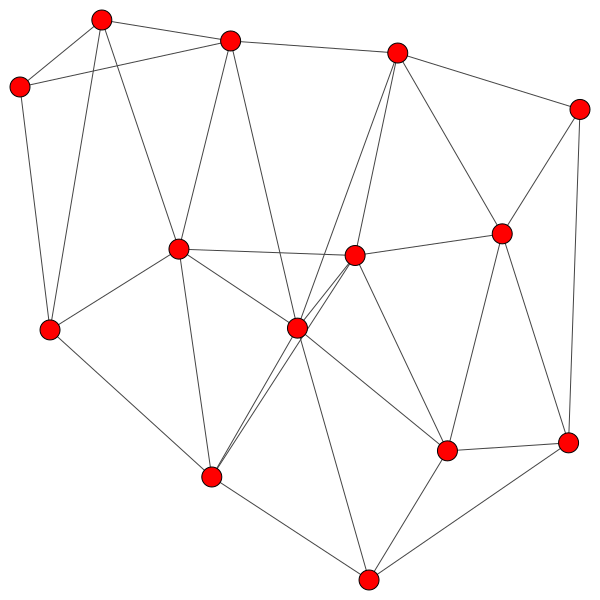

In [28]:
g = deform_code_for_logical(BB_code.matrix, Pauli.Z, BB_code.get_logical_ops(Pauli.Z)[0])["g"]
plot(g)
# enumerate vertices and place on a 1d strip
# enumerate edges for all cycles and place them on a 

In [ ]:
vertices = g.vs()
edges = g.es()


# Visualise the idea
# plot the vertices in small circles in a straight line to the right
# draw a 6 x 8 triangular grid to the left of the vertices 


